<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/04_Airbnb_Berlin_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install missingno
# !pip install geopy

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')

# Feature Engineering

## Declare data columns Lists

In [ ]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
num_non_dummy_columns = numerical_columns + rating_columns + categorical_encoded_columns + geo_columns

In [ ]:
df = df_Feature_Engineering.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        23536 non-null  float64
 1   Bathrooms              23536 non-null  float64
 2   Checkin Rating         23536 non-null  float64
 3   Cleanliness Rating     23536 non-null  float64
 4   Communication Rating   23536 non-null  float64
 5   Latitude               23536 non-null  float64
 6   Location Rating        23536 non-null  float64
 7   Longitude              23536 non-null  float64
 8   Overall Rating         23536 non-null  float64
 9   Price                  23536 non-null  float64
 10  Value Rating           23536 non-null  float64
 11  Comments               23536 non-null  object 
 12  Host Since             23515 non-null  object 
 13  Host Response Time     23536 non-null  object 
 14  Is Superhost           23536 non-null  bool   
 15  ne

In [ ]:
df.isnull().sum()

,0
Accuracy Rating,0
Bathrooms,0
Checkin Rating,0
Cleanliness Rating,0
Communication Rating,0
Latitude,0
Location Rating,0
Longitude,0
Overall Rating,0
Price,0


## Listing Distance from Berline center

In [ ]:
from geopy.distance import great_circle
def distance_to_mid(lat, lon):
    berlin_centre = (52.5027778, 13.404166666666667)
    accommodation = (lat, lon)
    return great_circle(berlin_centre, accommodation).km

df['Distance From Center'] = df.apply(lambda row: round(distance_to_mid(row['Latitude'], row['Longitude']), 1), axis=1)

In [ ]:
df['Distance From Center'].max()

25.0

bin continuous values into discrete intervals

In [ ]:
max_Distance_From_Center = int(df['Distance From Center'].max())
bins = [0, 0.5, 1, 2, 4, 6, 8, 10 , 12, max_Distance_From_Center]
labels = ["km_0", "km_0.5", "km_1", "km_2", "km_4", "km_8", "km_10", "km_12", f"km_{max_Distance_From_Center}"]

# Apply pd.cut() to create a new binned column
df["Distance From Center Reduced"] = pd.cut(df["Distance From Center"], bins=bins, labels=labels, include_lowest=True)
df.head(2)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Latitude,Location Rating,Longitude,Overall Rating,Price,Value Rating,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced,Distance From Center,Distance From Center Reduced
0,10.0,1.0,10.0,10.0,10.0,52.54851,9.0,13.40455,100.0,17.0,10.0,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2.0,1.0,1.0,1.0,2.000000,7.0,Apartment,10,5.1,km_4
1,9.0,1.0,9.0,9.0,9.0,52.53500,10.0,13.41758,92.0,90.0,9.0,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4.0,1.0,2.0,2.0,1.727273,144.0,Apartment,10,3.7,km_2


In [ ]:
df[['Distance From Center', 'Distance From Center Reduced']]

,Distance From Center,Distance From Center Reduced
0,5.1,km_4
1,3.7,km_2
2,4.6,km_4
3,3.5,km_2
4,5.0,km_4
...,...,...
23531,18.7,km_25
23532,15.4,km_25
23533,5.9,km_4
23534,12.7,km_25


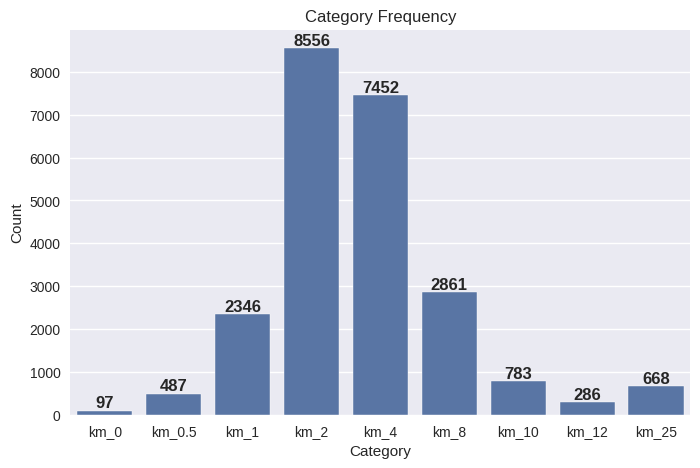

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 5))

# Create count plot
ax = sns.countplot(x='Distance From Center Reduced', data=df)

# Add count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Category Frequency')

plt.show()

## Extracting years from date columns

In [ ]:
from datetime import datetime
df['Host Since'] = pd.to_datetime(df['Host Since'])
df['Host Since Year'] = df['Host Since'].dt.year.astype('str').apply(lambda x: (x.split('.')[0]))
df['Host Since Year'] = df['Host Since Year'].apply(lambda x: None if x == 'nan' else x).astype('category')

# Get the current year
current_year = datetime.now().year

# Calculate the difference in years
df['Host Since From Now'] = current_year - df['Host Since'].dt.year
df['Host Since From Now'] = df['Host Since From Now'].fillna(0).astype('int')


In [ ]:
df['Neighborhood Group'].unique()

array(['Pankow', 'Friedrichshain-Kreuzberg', 'NeukÃ¶lln', 'Mitte',
       'Charlottenburg-Wilm.', 'Tempelhof - SchÃ¶neberg',
       'Treptow - KÃ¶penick', 'Steglitz - Zehlendorf', 'Reinickendorf',
       'Lichtenberg', 'Marzahn - Hellersdorf', 'Spandau'], dtype=object)

In [ ]:
df.groupby(['Neighborhood Group', 'neighbourhood'])['neighbourhood'].count()

Neighborhood Group    neighbourhood      
Charlottenburg-Wilm.  Charlottenburg         858
                      Charlottenburg-Nord     18
                      Grunewald               50
                      Halensee                67
                      Schmargendorf           35
                                            ... 
Treptow - KÃ¶penick   NiederschÃ¶neweide      24
                      OberschÃ¶neweide        53
                      PlÃ¤nterwald            56
                      Rahnsdorf               28
                      SchmÃ¶ckwitz            22
Name: neighbourhood, Length: 108, dtype: int64

## Store dataset

In [ ]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Selection.pkl")